# FEATURE SELECTION

In [3]:
import pandas as pd

In [4]:
master_df = pd.read_csv("../data/processed_data/master_dataframe.csv")
master_df["date"] = pd.to_datetime(master_df["date"])

master_df.head()

,date,nf_Adj Close,nf_Close,nf_High,nf_Low,nf_Open,nf_Volume,bnf_Adj Close,bnf_Close,bnf_High,...,vix_level,vix_change,vix_5d_change,vix_ma_ratio,close_vs_252d_high,close_vs_252d_low,dow,ret_zscore,ma5_smooth_signal,volume_normalized
0,2022-01-03,17625.699219,17625.699219,17646.650391,17383.300781,17387.150391,200500,36421.476562,36421.898438,36492.101562,...,16.450001,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0.180301
1,2022-01-04,17805.250000,17805.250000,17827.599609,17593.550781,17681.400391,247400,36839.718750,36840.148438,36887.800781,...,16.120001,-0.020061,NaN,NaN,NaN,NaN,1,1.144972,NaN,0.228022
2,2022-01-05,17925.250000,17925.250000,17944.699219,17748.849609,17820.099609,251500,37695.460938,37695.898438,37862.398438,...,17.230000,0.068858,NaN,NaN,NaN,NaN,2,0.740212,0.008001,0.232194
3,2022-01-06,17745.900391,17745.900391,17797.949219,17655.550781,17768.500000,236500,37489.812500,37490.250000,37752.500000,...,17.980000,0.043529,NaN,NaN,NaN,NaN,3,-1.225885,-0.006304,0.216931
4,2022-01-07,17812.699219,17812.699219,17905.000000,17704.550781,17797.599609,239300,37739.164062,37739.601562,38134.851562,...,17.600000,-0.021135,NaN,NaN,NaN,NaN,4,0.390858,-0.005354,0.219780


In [5]:
# selected features and rejected features

selected_features = [
    "ret_1d",        
    "ret_overnight",        
    "ret_5d",           
    "close_vs_ma5",    
    "momentum_5_20",    
    "vol_20d",          
    "vix_change",       
    "vix_ma_ratio",     
    "bn_ret_1d",        
    "nifty_bn_spread",  
    "ret_zscore",       
    "high_low_range"    
]

rejected_features = [
    "ret_10d",
    "ret_20d",
    "ret_intraday",
    "bn_ret_5d",
    "vol_5d",
    "vol_50d",
    "vix_level",
    "vix_5d_change",
    "log_volume",
    "volume_ratio_20d",
    "volume_normalized",
    "close_vs_ma20",
    "close_vs_ma50",
    "ma5_smooth_signal",
    "rsi_14",
    "nifty_bn_corr_20d",
    "close_vs_252d_high",
    "close_vs_252d_low",
    "dow"
]

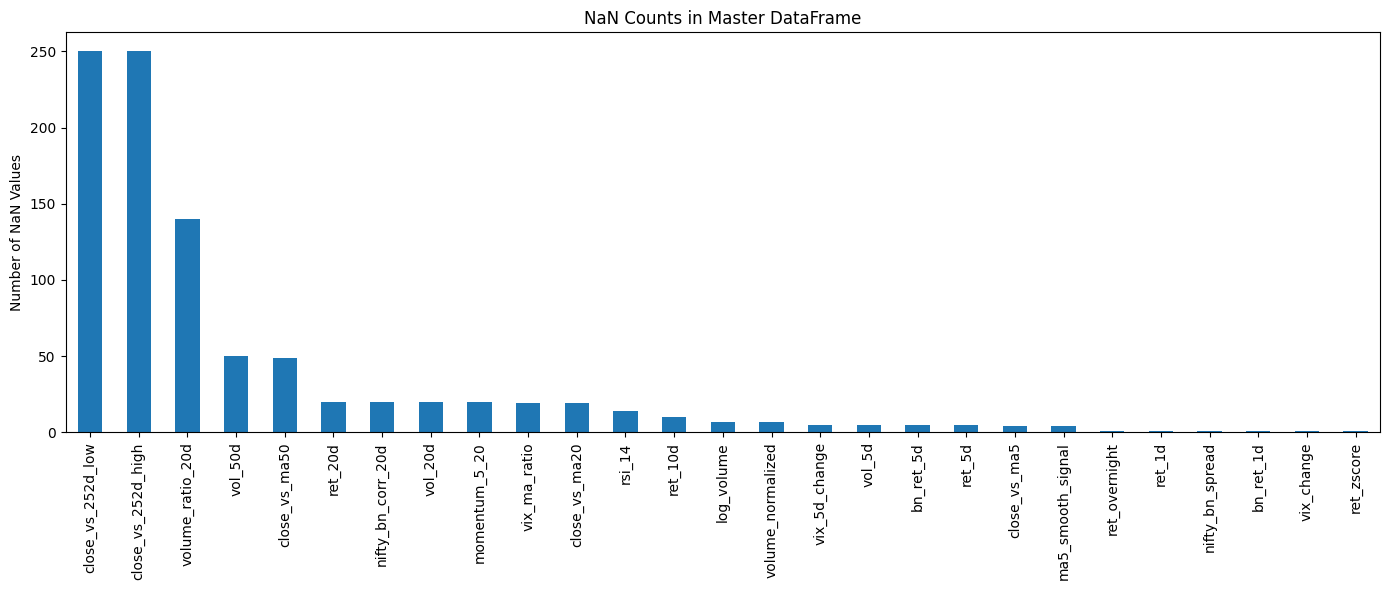

In [7]:
# NaN count in master_df
import matplotlib.pyplot as plt

nan_counts = master_df.isna().sum()

nan_counts = nan_counts[nan_counts > 0]

plt.figure(figsize=(14,6))

nan_counts.sort_values(ascending=False).plot(
    kind='bar'
)

plt.title("NaN Counts in Master DataFrame")
plt.ylabel("Number of NaN Values")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## Feature Statistics

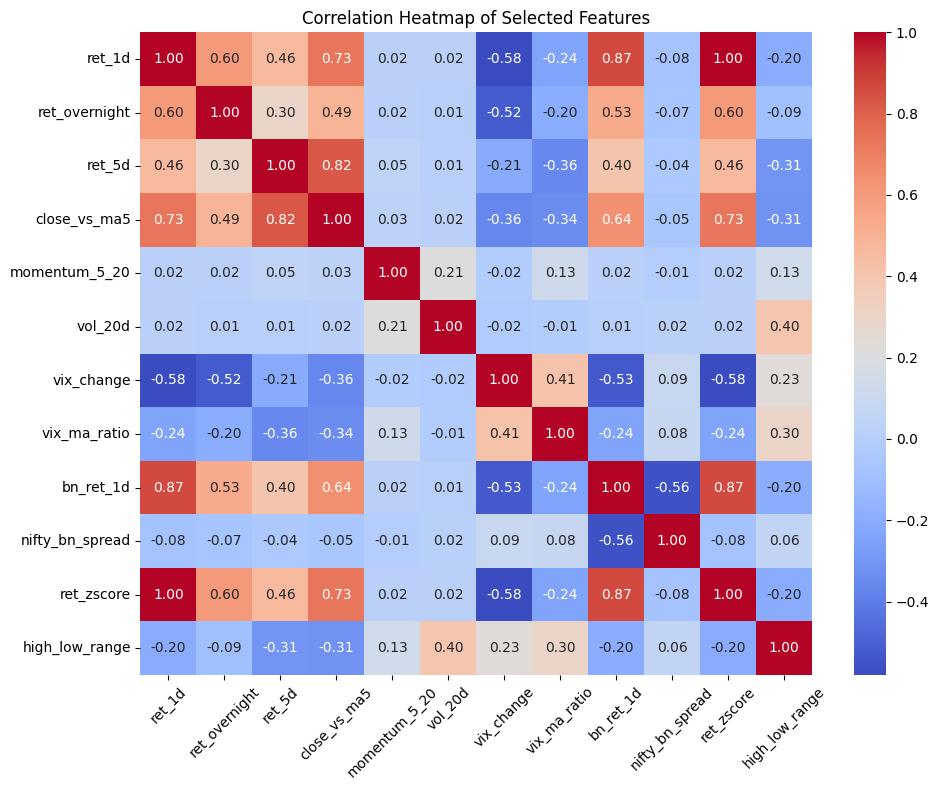

In [9]:
# corr. matrix

import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = master_df[selected_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Selected Features")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Target definition

In [12]:
model_df = master_df[["date"] + selected_features + ["nf_Close"]].copy()    # 12 selected features + closing target(next day)
model_df.head()

,date,ret_1d,ret_overnight,ret_5d,close_vs_ma5,momentum_5_20,vol_20d,vix_change,vix_ma_ratio,bn_ret_1d,nifty_bn_spread,ret_zscore,high_low_range,nf_Close
0,2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.014941,17625.699219
1,2022-01-04,0.010187,0.003160,NaN,NaN,NaN,NaN,-0.020061,NaN,0.011483,-0.001297,1.144972,0.013145,17805.250000
2,2022-01-05,0.006740,0.000834,NaN,NaN,NaN,NaN,0.068858,NaN,0.023229,-0.016489,0.740212,0.010926,17925.250000
3,2022-01-06,-0.010005,-0.008745,NaN,NaN,NaN,NaN,0.043529,NaN,-0.005455,-0.004550,-1.225885,0.008024,17745.900391
4,2022-01-07,0.003764,0.002913,NaN,0.001672,NaN,NaN,-0.021135,NaN,0.006651,-0.002887,0.390858,0.011253,17812.699219


In [13]:
# target => 1-nxt day mkt close went up (wrt today's data)
# target => 0-nxt day mkt close went down (wrt today's data)
model_df["target"] = ( model_df["nf_Close"].shift(-1) > model_df["nf_Close"] ).astype(int)

# removed last row because Jan 1, 2026 data is unavailable, above code line gives NaN; .astype(int) converts to 0, which may not be true
model_df = model_df.iloc[:-1]

model_df.head()

,date,ret_1d,ret_overnight,ret_5d,close_vs_ma5,momentum_5_20,vol_20d,vix_change,vix_ma_ratio,bn_ret_1d,nifty_bn_spread,ret_zscore,high_low_range,nf_Close,target
0,2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.014941,17625.699219,1
1,2022-01-04,0.010187,0.003160,NaN,NaN,NaN,NaN,-0.020061,NaN,0.011483,-0.001297,1.144972,0.013145,17805.250000,1
2,2022-01-05,0.006740,0.000834,NaN,NaN,NaN,NaN,0.068858,NaN,0.023229,-0.016489,0.740212,0.010926,17925.250000,0
3,2022-01-06,-0.010005,-0.008745,NaN,NaN,NaN,NaN,0.043529,NaN,-0.005455,-0.004550,-1.225885,0.008024,17745.900391,1
4,2022-01-07,0.003764,0.002913,NaN,0.001672,NaN,NaN,-0.021135,NaN,0.006651,-0.002887,0.390858,0.011253,17812.699219,1


In [14]:
model_df = model_df.drop(columns=["nf_Close"])
display(model_df.head())
display(model_df.shape)

,date,ret_1d,ret_overnight,ret_5d,close_vs_ma5,momentum_5_20,vol_20d,vix_change,vix_ma_ratio,bn_ret_1d,nifty_bn_spread,ret_zscore,high_low_range,target
0,2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.014941,1
1,2022-01-04,0.010187,0.003160,NaN,NaN,NaN,NaN,-0.020061,NaN,0.011483,-0.001297,1.144972,0.013145,1
2,2022-01-05,0.006740,0.000834,NaN,NaN,NaN,NaN,0.068858,NaN,0.023229,-0.016489,0.740212,0.010926,0
3,2022-01-06,-0.010005,-0.008745,NaN,NaN,NaN,NaN,0.043529,NaN,-0.005455,-0.004550,-1.225885,0.008024,1
4,2022-01-07,0.003764,0.002913,NaN,0.001672,NaN,NaN,-0.021135,NaN,0.006651,-0.002887,0.390858,0.011253,1


(982, 14)

## Final model dataset formation

In [16]:
# removing NaN

model_df = model_df.dropna()
display(model_df.head())
display(model_df.shape)

,date,ret_1d,ret_overnight,ret_5d,close_vs_ma5,momentum_5_20,vol_20d,vix_change,vix_ma_ratio,bn_ret_1d,nifty_bn_spread,ret_zscore,high_low_range,target
20,2022-02-01,0.013668,0.010934,0.024943,0.017099,0.027714,0.010473,-0.089749,1.074916,0.013960,-0.000292,1.553698,0.021497,1
21,2022-02-02,0.011558,0.007359,0.029057,0.022911,0.030475,0.010548,-0.066567,0.996580,0.021426,-0.009868,1.305943,0.006738,0
22,2022-02-03,-0.012362,-0.000689,0.026303,0.005061,0.046668,0.010766,0.027346,1.018580,-0.008149,-0.004213,-1.502610,0.015376,0
23,2022-02-04,-0.002500,0.001708,0.024228,-0.002184,0.037167,0.010564,-0.013570,1.002307,-0.005656,0.003156,-0.344630,0.008863,0
24,2022-02-07,-0.017281,-0.003425,-0.007281,-0.018015,0.026352,0.011139,0.081482,1.075874,-0.020467,0.003186,-2.080153,0.024245,1


(962, 14)

In [17]:
# handling 0s (replacement for missing data, which may cause misdirection)
(model_df == 0).sum()
# zeros, where present are valid mathematically and logically

date                 0
ret_1d               1
ret_overnight        0
ret_5d               0
close_vs_ma5         0
momentum_5_20        0
vol_20d              0
vix_change           8
vix_ma_ratio         0
bn_ret_1d            0
nifty_bn_spread      0
ret_zscore           0
high_low_range       0
target             453
dtype: int64

In [18]:
model_df.to_csv("../data/processed_data/final_model_dataset.csv", index=False)

model_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 962 entries, 20 to 981
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             962 non-null    datetime64[ns]
 1   ret_1d           962 non-null    float64       
 2   ret_overnight    962 non-null    float64       
 3   ret_5d           962 non-null    float64       
 4   close_vs_ma5     962 non-null    float64       
 5   momentum_5_20    962 non-null    float64       
 6   vol_20d          962 non-null    float64       
 7   vix_change       962 non-null    float64       
 8   vix_ma_ratio     962 non-null    float64       
 9   bn_ret_1d        962 non-null    float64       
 10  nifty_bn_spread  962 non-null    float64       
 11  ret_zscore       962 non-null    float64       
 12  high_low_range   962 non-null    float64       
 13  target           962 non-null    int64         
dtypes: datetime64[ns](1), float64(12), int64(1)
me